In [1]:
building = 26

# Setup

In [2]:
import torch
import torch.nn.functional as F
import math
import pandas as pd
import cvxpy as cp

import src.data.dataprep as prep
import src.data.featurisation as features

from src.models.lstm import LSTM
from src.models.lstmopt import LSTMOPT
from src.models.lstmopt import CVXLayer

from src.training.training import  Training as Training
from src.training.training_opt import Training as Training_opt

import src.optimization.pv_battery as pvb

import src.tensors.tensorisation as tensor

import src.util.formulas as fm

def torch_py(torch_tensor):
    return torch_tensor.cpu().detach().numpy().flatten()

def rescale(values, scaler):
    rescaled_values = values * (scaler[1] - scaler[0]) + scaler[0]   
    return rescaled_values

In [3]:
nl_data = prep.dutch_data('../../data/Dutchdata_clean/building_' + str(building) + '.parquet', 'h')



nl_data.loc[:,'offtake'] = nl_data.index.to_series().apply(lambda x: assign_value(x.time(),0.2,0.3))
nl_data.loc[:,'injection'] = nl_data.index.to_series().apply(lambda x: assign_value(x.time(),0.05,0.01))
nl_data['net_load'] = nl_data['load'] - nl_data['solar_energy']
nl_data['cost'] = nl_data.apply(lambda row: row['net_load'] * row['injection'] if row['net_load'] < 0 else row['net_load'] * row['offtake'], axis=1)

NameError: name 'assign_value' is not defined

In [4]:
nl_data.head()

,load,solar_energy,offtake,injection,net_load,cost
timestamp,,,,,,
2018-07-01 00:00:00,0.4552,0.0,0.2,0.05,0.4552,0.09104
2018-07-01 01:00:00,0.2256,0.0,0.2,0.05,0.2256,0.04512
2018-07-01 02:00:00,0.1862,0.0,0.2,0.05,0.1862,0.03724
2018-07-01 03:00:00,0.1860,0.0,0.2,0.05,0.1860,0.03720
2018-07-01 04:00:00,0.1870,0.0,0.2,0.05,0.1870,0.03740


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Optimization problems

In [6]:
# Base parameters
battery_capacity = math.floor(nl_data['load'].resample('D').sum().max())
max_charge = battery_capacity/2.7
max_discharge = max_charge
T = 24
epochs = 100

### Actual optimization problem

In [7]:
imp = cp.Variable(T)
exp = cp.Variable(T)
bat_energy = cp.Variable(T+1)
mode = cp.Variable(T)
bat_charge = cp.Variable(T)
bat_discharge = cp.Variable(T)
variables = [imp, exp, bat_energy, mode, bat_charge, bat_discharge]

load = cp.Parameter(T)
off = cp.Parameter(T)
inj = cp.Parameter(T)
pv = cp.Parameter(T)
initial_battery_energy = cp.Parameter()

parameters = [pv, load, off, inj, initial_battery_energy]

objective = cp.Minimize(cp.sum(imp @  off - exp @ inj))

constraints = [
    pv + imp + bat_discharge == exp + load + bat_charge,
    exp >= 0,
    imp >= 0,
    bat_charge >= 0,
    bat_discharge >= 0,
    bat_charge <= max_charge * (1-mode),
    bat_discharge <= max_discharge * mode,
    bat_energy[0] == initial_battery_energy,
    bat_energy[-1] == battery_capacity * 0.5,
    bat_energy >= battery_capacity * 0.2,
    bat_energy <= battery_capacity * 0.8,
    mode >= 0,
    mode <= 1
    ]

for t in range(1,T+1):
    constraints += [
        bat_energy[t] == bat_energy[t-1] + bat_charge[t-1] - bat_discharge[t-1]
    ]
    
problem = cp.Problem(objective, constraints)

### Optimization problem post forecasting

In [8]:
imp_fcst = cp.Variable(T)
exp_fcst = cp.Variable(T)
bat_energy_fcst = cp.Variable(T+1)
variables_fcst = [imp_fcst, exp_fcst, bat_energy_fcst]

load_fcst = cp.Parameter(T)
off_fcst = cp.Parameter(T)
inj_fcst = cp.Parameter(T)
pv_fcst = cp.Parameter(T)
initial_battery_energy_fcst = cp.Parameter()
bat_charge_fcst = cp.Parameter(T)
bat_discharge_fcst = cp.Parameter(T)

parameters_fcst = [pv_fcst, load_fcst, off_fcst, inj_fcst, initial_battery_energy_fcst, bat_charge_fcst, bat_discharge_fcst]

objective_fcst = cp.Minimize(cp.sum(imp_fcst @  off_fcst - exp_fcst @ inj_fcst))

constraints_fcst = [
    pv_fcst + imp_fcst + bat_discharge_fcst == exp_fcst + load_fcst + bat_charge_fcst,
    exp_fcst >= 0,
    imp_fcst >= 0,
    bat_energy_fcst[0] == initial_battery_energy_fcst,
    bat_energy_fcst[-1] == initial_battery_energy_fcst,
    bat_energy_fcst >= battery_capacity*0.05,
    bat_energy_fcst <= battery_capacity*0.95
    ]

for t in range(1,T+1):
    constraints_fcst += [
        bat_energy_fcst[t] == bat_energy_fcst[t-1] + bat_charge_fcst[t-1] - bat_discharge_fcst[t-1]
    ]
    
problem_fcst = cp.Problem(objective_fcst, constraints_fcst)

# LSTM model

## Tensors

In [9]:
# Tensors for training
nl_tensors = tensor.Tensors(nl_data,'solar_energy',['solar_energy'],[],24,24)
X_train_base, X_test_base, y_train_base, y_test_base, scalers = nl_tensors.create_tensor()

## Model

In [10]:
lstm = LSTM(1,200,3,24,0.5).to(device)

In [11]:
X_train_base.shape

torch.Size([901, 24, 1])

In [12]:
trainer_base = Training(lstm, X_train_base, y_train_base, X_test_base, y_test_base, epochs)

In [13]:
state_dicts_lstm, best_lstm = trainer_base.fit()

Best Epoch: 80


In [14]:
lstm.load_state_dict(state_dicts_lstm[best_lstm])

<All keys matched successfully>

# LSTM-CVX model

## Tensors

In [15]:
# Tensors for training
nl_opt_tensors = tensor.Tensors(nl_data,'solar_energy',['solar_energy'],['load','offtake','injection'],24,24, domain_min=[None, 0, 0, 0, None], domain_max=[None, 1, 1, 1, None])
X_train, X_test, _, _, scalers_opt = nl_opt_tensors.create_tensor()

nl_normal_tensors = tensor.Tensors(nl_data,'solar_energy',['solar_energy'],[],24,24)
_, _, y_train_pv, y_test_pv, scalers_normal = nl_normal_tensors.create_tensor()

In [16]:
y_test_pv.shape

torch.Size([225, 24])

In [17]:
cvx_real = CVXLayer(problem, parameters, variables)

In [18]:
cvx_vars_train = cvx_real(rescale(y_train_pv,scalers_opt[0]),
                          X_train[:,:,1],
                          X_train[:,:,2],
                          X_train[:,:,3],
                          torch.full([y_train_pv.shape[0]],battery_capacity*0.5))

cvx_vars_test = cvx_real(rescale(y_test_pv,scalers_opt[0]),
                         X_test[:,:,1],
                         X_test[:,:,2],
                         X_test[:,:,3],
                         torch.full([y_test_pv.shape[0]],battery_capacity*0.5))

In [19]:
solution_train = (torch.bmm(cvx_vars_train[0].unsqueeze(1), X_train[:,:,2].unsqueeze(-1)) -
                  torch.bmm(cvx_vars_train[1].unsqueeze(1), X_train[:,:,3].unsqueeze(-1)))

solution_test = (torch.bmm(cvx_vars_test[0].unsqueeze(1), X_test[:,:,2].unsqueeze(-1)) -
                 torch.bmm(cvx_vars_test[1].unsqueeze(1), X_test[:,:,3].unsqueeze(-1)))

In [20]:
y_train_solution = F.pad(solution_train,(0,0,0,23))
y_test_solution = F.pad(solution_test,(0,0,0,23))

In [21]:
y_train = torch.cat([y_train_pv.unsqueeze(-1), y_train_solution], dim=-1)
y_test = torch.cat([y_test_pv.unsqueeze(-1), y_test_solution], dim=-1)

## Model

In [22]:
lstm_opt = LSTMOPT(1,200,3,24,0.5,problem,parameters,variables,scalers_opt[0]).to(device)
lstm_opt_transfer = LSTMOPT(1,200,3,24,0.5,problem,parameters,variables,scalers_opt[0]).to(device)
cvx_fcst = CVXLayer(problem_fcst, parameters_fcst, variables_fcst)

In [26]:
trainer = Training_opt(lstm_opt, cvx_fcst, X_train, y_train, X_test, y_test, scalers_opt[0], epochs, T, battery_capacity, min_beta=1, max_beta=1, learning_rate=0.0001, lr_decay=None)
trainer_transfer = Training_opt(lstm_opt_transfer, cvx_fcst, X_train, y_train, X_test, y_test, scalers_opt[0], epochs, T, battery_capacity, min_beta=1, learning_rate=0.0001, lr_decay=None)

In [27]:
state_dicts_cvx, best_cvx = trainer.fit()

Training interrupted due to error: input.size(-1) must be equal to input_size. Expected 1, got 0
Returning progress up to this point...
Best Epoch: -1


In [28]:
lstm_opt.load_state_dict(state_dicts_cvx[best_cvx])

IndexError: list index out of range

In [91]:
lstm_opt_transfer.load_state_dict(lstm.state_dict())

<All keys matched successfully>

Step 0: Average train loss: 0.0031 | Average test loss: 0.0034

MSE: 0.00 | Regret: 1.00
Step 5: Average train loss: 0.0023 | Average test loss: 0.0029
Step 10: Average train loss: 0.0022 | Average test loss: 0.0028

MSE: 0.00 | Regret: 1.00
Step 15: Average train loss: 0.0022 | Average test loss: 0.0027
Step 20: Average train loss: 0.0022 | Average test loss: 0.0027

MSE: 0.00 | Regret: 1.00
Step 25: Average train loss: 0.0021 | Average test loss: 0.0027
Step 30: Average train loss: 0.0021 | Average test loss: 0.0027

MSE: 0.00 | Regret: 1.00
Step 35: Average train loss: 0.0021 | Average test loss: 0.0027
Step 40: Average train loss: 0.0021 | Average test loss: 0.0027

MSE: 0.00 | Regret: 1.00
Step 45: Average train loss: 0.0021 | Average test loss: 0.0027
Step 50: Average train loss: 0.0021 | Average test loss: 0.0028

MSE: 0.00 | Regret: 1.00
Step 55: Average train loss: 0.0021 | Average test loss: 0.0028
Step 60: Average train loss: 0.0021 | Average test loss: 0.0028

MSE: 0.00 | R

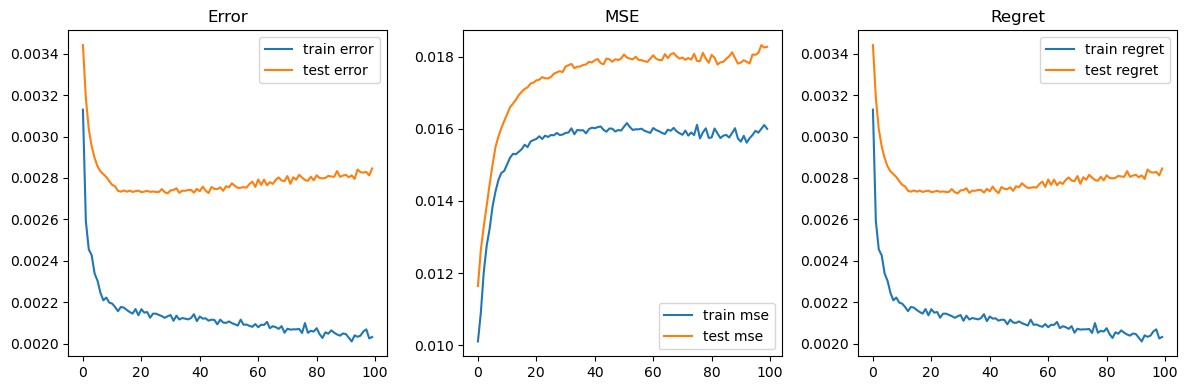

In [92]:
state_dicts_transfer, best_transfer = trainer_transfer.fit()

In [93]:
lstm_opt_transfer.load_state_dict(state_dicts_transfer[best_transfer])

<All keys matched successfully>

Evaluation

In [94]:
pv_lstm = lstm(X_test_base.to(device))

pv_sol, _ = lstm_opt(X_test[:,:,0].unsqueeze(-1).to(device), 
                     X_test[:,:,1].to(device), 
                     X_test[:,:,2].to(device), 
                     X_test[:,:,3].to(device), 
                     torch.full([X_test.shape[0]],battery_capacity*0.5).to(device))

pv_sol_transfer, _ = lstm_opt_transfer(X_test[:,:,0].unsqueeze(-1).to(device), 
                                       X_test[:,:,1].to(device), 
                                       X_test[:,:,2].to(device), 
                                       X_test[:,:,3].to(device), 
                                       torch.full([X_test.shape[0]],battery_capacity*0.5).to(device))

In [95]:
cvx_solutions = []
cvx_real_solutions = []
cvx_transfer_solutions = []
cvx_transfer_real_solutions = []
lstm_solutions = []
lstm_real_solutions = []
naive_solutions = []
naive_real_solutions = []
opt_solutions = []

for i in range(len(X_test)):   
    # CVX forecast
    pv.value = torch_py(rescale(pv_sol[i], scalers_opt[0]))
    load.value = torch_py(X_test[i,:,1])
    off.value = torch_py(X_test[i,:,2])
    inj.value = torch_py(X_test[i,:,3])
    initial_battery_energy.value = battery_capacity * 0.5
    cvx_solutions.append(problem.solve())

    # CVX real
    pv_fcst.value = torch_py(rescale(y_test[i,:,0], scalers_normal[0]))
    load_fcst.value = torch_py(X_test[i,:,1])
    off_fcst.value = torch_py(X_test[i,:,2])
    inj_fcst.value = torch_py(X_test[i,:,3])
    initial_battery_energy_fcst.value = battery_capacity * 0.5
    bat_charge_fcst.value = bat_charge.value
    bat_discharge_fcst.value = bat_discharge.value    
    cvx_real_solutions.append(problem_fcst.solve())
    
    # CVX Transfer forecast
    pv.value = torch_py(rescale(pv_sol_transfer[i], scalers_opt[0]))
    load.value = torch_py(X_test[i,:,1])
    off.value = torch_py(X_test[i,:,2])
    inj.value = torch_py(X_test[i,:,3])
    initial_battery_energy.value = battery_capacity * 0.5
    cvx_transfer_solutions.append(problem.solve())

    # CVX real
    pv_fcst.value = torch_py(rescale(y_test[i,:,0], scalers_normal[0]))
    load_fcst.value = torch_py(X_test[i,:,1])
    off_fcst.value = torch_py(X_test[i,:,2])
    inj_fcst.value = torch_py(X_test[i,:,3])
    initial_battery_energy_fcst.value = battery_capacity * 0.5
    bat_charge_fcst.value = bat_charge.value
    bat_discharge_fcst.value = bat_discharge.value    
    cvx_transfer_real_solutions.append(problem_fcst.solve())

    # LSTM forecast
    pv.value = torch_py(rescale(pv_lstm[i], scalers[0]))
    load.value = torch_py(X_test[i,:,1])
    off.value = torch_py(X_test[i,:,2])
    inj.value = torch_py(X_test[i,:,3])
    initial_battery_energy.value = battery_capacity * 0.5
    lstm_solutions.append(problem.solve())

    # LSTM real
    pv_fcst.value = torch_py(rescale(y_test_base[i], scalers[0]))
    load_fcst.value = torch_py(X_test[i,:,1])
    off_fcst.value = torch_py(X_test[i,:,2])
    inj_fcst.value = torch_py(X_test[i,:,3])
    initial_battery_energy_fcst.value = battery_capacity * 0.5
    bat_charge_fcst.value = bat_charge.value
    bat_discharge_fcst.value = bat_discharge.value    
    lstm_real_solutions.append(problem_fcst.solve())
   
    # Naive forecast 
    pv.value = torch_py(rescale(X_test[i,:,0], scalers_opt[0]))
    load.value = torch_py(X_test[i,:,1])
    off.value = torch_py(X_test[i,:,2])
    inj.value = torch_py(X_test[i,:,3])
    initial_battery_energy.value = battery_capacity * 0.5
    naive_solutions.append(problem.solve())

    # Naive real
    pv_fcst.value = torch_py(rescale(y_test[i,:,0], scalers_normal[0]))
    load_fcst.value = torch_py(X_test[i,:,1])
    off_fcst.value = torch_py(X_test[i,:,2])
    inj_fcst.value = torch_py(X_test[i,:,3])
    initial_battery_energy_fcst.value = battery_capacity * 0.5
    bat_charge_fcst.value = bat_charge.value
    bat_discharge_fcst.value = bat_discharge.value    
    naive_real_solutions.append(problem_fcst.solve())
    
    # Perfect forecast
    pv.value = torch_py(rescale(y_test[i,:,0], scalers_normal[0]))
    load.value = torch_py(X_test[i,:,1])
    off.value = torch_py(X_test[i,:,2])
    inj.value = torch_py(X_test[i,:,3])
    initial_battery_energy.value = battery_capacity * 0.5
    opt_solutions.append(problem.solve())

In [96]:
rmse_cvx = fm.rmse(torch_py(pv_sol), torch_py(y_test[:,:,0]))
rmse_cvx_transfer = fm.rmse(torch_py(pv_sol_transfer), torch_py(y_test[:,:,0]))
rmse_lstm = fm.rmse(torch_py(pv_lstm), torch_py(y_test_base))
rmse_naive = fm.rmse(torch_py(X_test_base[:,:,0]), torch_py(y_test_base))

In [97]:
print(f"What LSTM-CVX predicted: {sum(cvx_solutions):.2f}\n"
      f"What we actually paid with LSTM-CVX: {sum(cvx_real_solutions):.2f}\n\n"
      f"What LSTM-CVX-Transfer predicted: {sum(cvx_transfer_solutions):.2f}\n"
      f"What we actually paid with LSTM-CVX-Transfer: {sum(cvx_transfer_real_solutions):.2f}\n\n"
      f"What LSTM predicted: {sum(lstm_solutions):.2f}\n"
      f"What we actually paid with LSTM: {sum(lstm_real_solutions):.2f}\n\n"
      f"What Naive predicted: {sum(naive_solutions):.2f}\n"
      f"What we actually paid with Naive: {sum(naive_real_solutions):.2f}\n\n"
      f"The optimal solution: {sum(opt_solutions):.2f}\n"
      f"What we pay with no battery: {sum(nl_data['cost']):.2f}")

What LSTM-CVX predicted: -22.16
What we actually paid with LSTM-CVX: -16.35

What LSTM-CVX-Transfer predicted: -27.19
What we actually paid with LSTM-CVX-Transfer: -16.02

What LSTM predicted: -30.12
What we actually paid with LSTM: -10.60

What Naive predicted: -28.30
What we actually paid with Naive: -10.79

The optimal solution: -28.34
What we pay with no battery: 213.63


In [98]:
print(f"The CVX RMSE: {rmse_cvx:.4f}\nThe CVX transfer RMSE: {rmse_cvx_transfer:.4f}\nThe LSTM RMSE: {rmse_lstm:.4f}\nThe Naive RMSE: {rmse_naive:.4f}")

The CVX RMSE: 0.1720
The CVX transfer RMSE: 0.1366
The LSTM RMSE: 0.1133
The Naive RMSE: 0.1364


In [99]:
lstm_cvx_metrics = [sum(cvx_solutions), sum(cvx_real_solutions), rmse_cvx, len(state_dicts_cvx), best_cvx]
lstm_cvx_transfer_metrics = [sum(cvx_transfer_solutions), sum(cvx_transfer_real_solutions), rmse_cvx_transfer, len(state_dicts_transfer), best_transfer]
lstm_metrics = [sum(lstm_solutions), sum(lstm_real_solutions), rmse_lstm, len(state_dicts_lstm), best_lstm]
naive_metrics = [sum(naive_solutions), sum(naive_real_solutions), rmse_naive, 0, 0]
optimal_metrics = [sum(nl_data['cost']), sum(opt_solutions), 0, 0, 0]

In [100]:
column_names = ['Solution', 'Real', 'RMSE', 'epochs', 'best']
all_metrics = pd.DataFrame([lstm_cvx_metrics, lstm_cvx_transfer_metrics, lstm_metrics, naive_metrics, optimal_metrics],
                           columns=column_names, 
                           index=['CVX', 'CVX Transfer', 'LSTM', 'Naive', 'Perfect'])


In [101]:
all_metrics

,Solution,Real,RMSE,epochs,best
CVX,-22.164180,-16.350551,0.172049,100,59
CVX Transfer,-27.194668,-16.022218,0.136633,100,29
LSTM,-30.119310,-10.602348,0.113292,100,90
Naive,-28.301276,-10.786293,0.136384,0,0
Perfect,-28.342952,213.634000,0.000000,0,0


In [102]:
all_metrics.to_csv('../results/building_' + str(building) + '.csv')